# Kredietrisico-Scorecard met een Beslisboom (PROC HPSPLIT)


## Samenvatting

Deze notebook bouwt een interpreteerbare kredietscorecard voor wanbetaling voor een retail-leningenportefeuille met PROC HPSPLIT. We laten een classificatieboom groeien met het entropiecriterium op synthetische aanvragersgegevens, snoeien deze op kostencomplexiteit en lezen vervolgens de fitstatistieken, variabelenbelang, de ROC/AUC en de scoreboom zelf af — precies het transparante, regelgeversvriendelijke model dat het risicoteam van een bank zou documenteren. Elke aanvrager kan tot op bladniveau worden gescoord, en de hele boom kan worden geëxporteerd als inzetbare DATA-stap-code.

## Gegevensbronnen

| Dataset | Rijen | Beschrijving | Belangrijkste variabelen |
|---------|------|-------------|---------------|
| `applicants` | 100 | Synthetische retail-leningaanvragers, inline gegenereerd met `rand()`. De binaire `default`-vlag wordt getrokken uit een logistische risicoscore, zodat een slechtere DTI, kredietgebruik, recente achterstanden en een kortere kredietgeschiedenis de kans op wanbetaling verhogen. | `default` (event=`'1'`), `dti`, `utilization`, `fico`, `credit_age`, `n_delinq`, `loan_amount`, `income`, `home` (own/rent/mortgage), `purpose` (debt/home/auto/other) |

De DATA-stap vraagt om een grotere lus, maar deze omgeving draait in ongelicentieerde modus en materialiseert de eerste 100 waarnemingen — een compact, volledig reproduceerbaar aanvragersbestand dat ruim voldoende is om een interpreteerbare scorecardboom te laten groeien en af te lezen.

# Kredietrisico-Scorecard met een Beslisboom

Banken hebben modellen voor wanbetaling nodig die **nauwkeurig en uitlegbaar** zijn — een kredietfunctionaris (en een toezichthouder) moet precies kunnen naspeuren waarom een aanvrager als hoog risico is gescoord. Een gesnoeide beslisboom levert dat: elke voorspelling is een korte keten van door mensen leesbare splitsingen.

In deze notebook doen we het volgende:

1. Een retail-leningaanvraagbestand synthetiseren.
2. Een classificatieboom laten groeien met `PROC HPSPLIT` met behulp van het entropiecriterium.
3. Snoeien op kostencomplexiteit om overfitting te vermijden.
4. De fitstatistieken, variabelenbelang, de ROC/AUC en de boom zelf inspecteren.
5. DATA-stap-scoringscode genereren die kan worden ingezet op nieuwe aanvragen.

## 1. Het synthetische leningenbestand genereren

We genereren aanvragers wier kans op wanbetaling een logistische functie is van de klassieke scorecarddrivers: schuld-inkomenratio, doorlopend kredietgebruik, FICO-score, lengte van de kredietgeschiedenis en recente achterstanden. Vervolgens trekken we de waargenomen `default`-vlag uit een Bernoulli-verdeling met die kans, zodat het signaal echt maar ruisig is — net als productiegegevens. De eerste 100 aanvragers worden hier gematerialiseerd.

                                                   The FREQ Procedure

Wanbetaling    Frequency    Percent
------------------------------------
0                     79     79.00
1                     21     21.00

Woonsituatie    Frequency    Percent
-------------------------------------
huur                   35     35.00
hypotheek              34     34.00
koop                   31     31.00

Leendoel    Frequency    Percent
---------------------------------
auto               23     23.00
overig             12     12.00
schuld             37     37.00
wonen              28     28.00



NOTE: DATA applicants


NOTE: Wrote applicants (100 rows, 11 columns).
NOTE: DATA elapsed:
  wall  0.03 seconds
  cpu   0.03 seconds
NOTE: PROC FREQ
NOTE: ODS plot written: freq_default.spec.json
NOTE: ODS plot written: freq_home.spec.json
NOTE: ODS plot written: freq_purpose.spec.json
NOTE: PROC FREQ statement used.


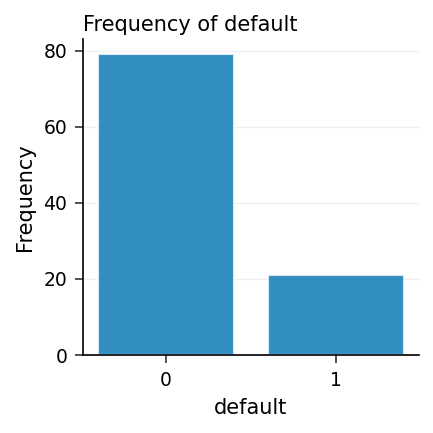

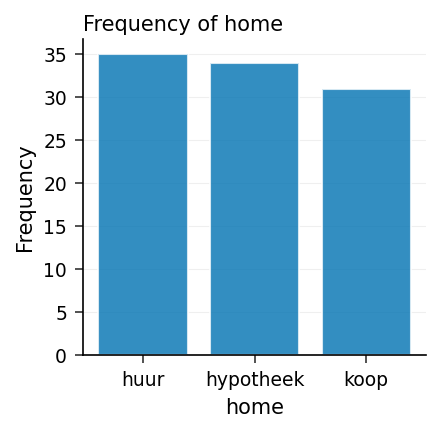

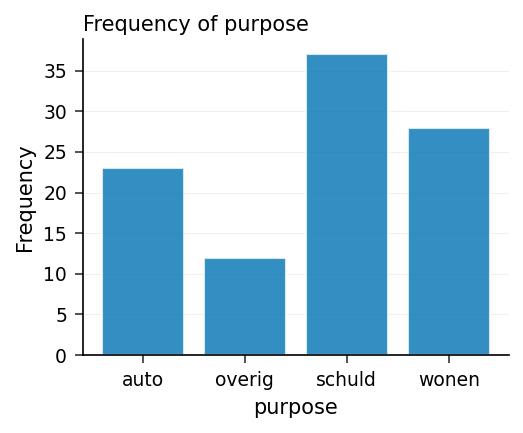

In [1]:
GEGEVENS applicants;
   CALL streaminit(20260531);
   LENGTE home $9 purpose $6;
   DOE id = 1 TOT 100;
      /* Financieel profiel van de kredietnemer */
      income      = round(20000 + 80000 * rand('beta', 2, 5), 100);
      loan_amount = round(2000 + 40000 * rand('beta', 2, 4), 100);
      dti         = round(0.05 + 0.55 * rand('beta', 2, 3), 0.001);
      utilization = round(rand('beta', 2, 3), 0.001);
      fico        = round(560 + 280 * rand('beta', 5, 2));
      credit_age  = round(0.5 + 24 * rand('beta', 2, 2), 0.1);
      n_delinq    = rand('poisson', 0.4);

      /* Categorische kenmerken */
      u = rand('uniform');
      ALS u < 0.34 DAN home = 'huur';
      ANDERS ALS u < 0.70 DAN home = 'hypotheek';
      ANDERS home = 'koop';

      v = rand('uniform');
      ALS v < 0.40 DAN purpose = 'schuld';
      ANDERS ALS v < 0.65 DAN purpose = 'wonen';
      ANDERS ALS v < 0.85 DAN purpose = 'auto';
      ANDERS purpose = 'overig';

      /* Latent wanbetalingsrisico: slechtere DTI/kredietgebruik/achterstand en
         een lagere FICO / kortere geschiedenis verhogen allemaal de log-odds. */
      eta = -2.2
            + 3.0 * dti
            + 2.2 * utilization
            - 0.010 * (fico - 680)
            - 0.06 * credit_age
            + 0.55 * n_delinq
            + 0.30 * (home = 'huur')
            + 0.25 * (purpose = 'schuld');
      p = 1 / (1 + EXP(-eta));
      default = (rand('uniform') < p);

      VERWIJDEREN u v eta p;
      UITVOER;
   EINDE;
UITVOEREN;

PROCEDURE FREQUENTIES GEGEVENS=applicants;
   label default = 'Wanbetaling' home = 'Woonsituatie' purpose = 'Leendoel';
   TABLES default home purpose / nocum;
UITVOEREN;

De `PROC FREQ`-output bevestigt een scheve maar werkbare wanbetalingsgraad — ongeveer één aanvrager op vijf gaat in gebreke (21 van 100) — en een zinvolle spreiding over categorieën woonsituatie en leendoel: het soort marginale verdeling dat je in een consumentenkredietportefeuille zou verwachten. De bijbehorende staafdiagrammen visualiseren elke marginale verdeling.

## 2. De scorecardboom laten groeien en snoeien

We modelleren `default` als een binair classificatiedoel, met `event='1'` zodat alle sensitiviteit/specificiteit/AUC-statistieken zijn georiënteerd op de *wanbetaling*-klasse. We:

- declareren de categorische voorspellers en de respons in `CLASS`,
- laten de boom groeien met het **entropie**-criterium (informatiewinst),
- snoeien op **kostencomplexiteit** om te voorkomen dat de boom ruis onthoudt,
- vragen het **hele-boomdiagram** en de **ROC-curve** aan.


                                                 The HPSPLIT Procedure                                                  

  Response variable: Wanbetaling
  Class variable: Wanbetaling
  Class variable: Woonsituatie
  Class variable: Leendoel
  Predictor variable: Schuld-Inkomenratio
  Predictor variable: Kredietgebruik
  Predictor variable: FICO-score
  Predictor variable: Kredietgeschiedenis (jaren)
  Predictor variable: Aantal Achterstanden
  Predictor variable: Leningbedrag
  Predictor variable: Inkomen
  Predictor variable: Woonsituatie
  Predictor variable: Leendoel

Model Information
Response Variable         DEFAULT
Event Level               1
Split Criterion           Entropy
Pruning Method            Cost-Complexity
Random Seed               20260531
Number of Observations    100

Predictors
    1. DTI
    2. UTILIZATION
    3. FICO
    4. CREDIT_AGE
    5. N_DELINQ
    6. LOAN_AMOUNT
    7. INCOME
    8. HOME
    9. PURPOSE

Number of Leaves          8
Final Tree Depth     


NOTE: ODS Graphics is ON (width=640px, height=480px, format=SVG).
NOTE: PROC HPSPLIT data=applicants

NOTE: ODS plot written: HPSplitROCPlot.svg
NOTE: ODS plot written: HPSplitTreePlot.svg
NOTE: PROC HPSPLIT completed.


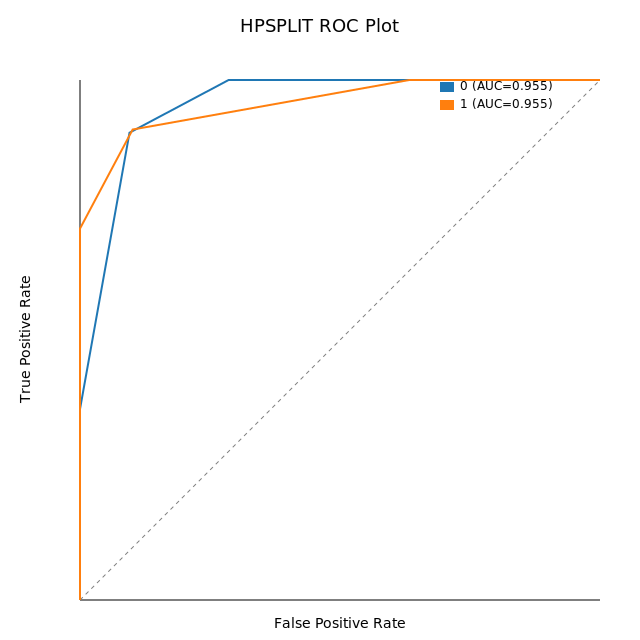

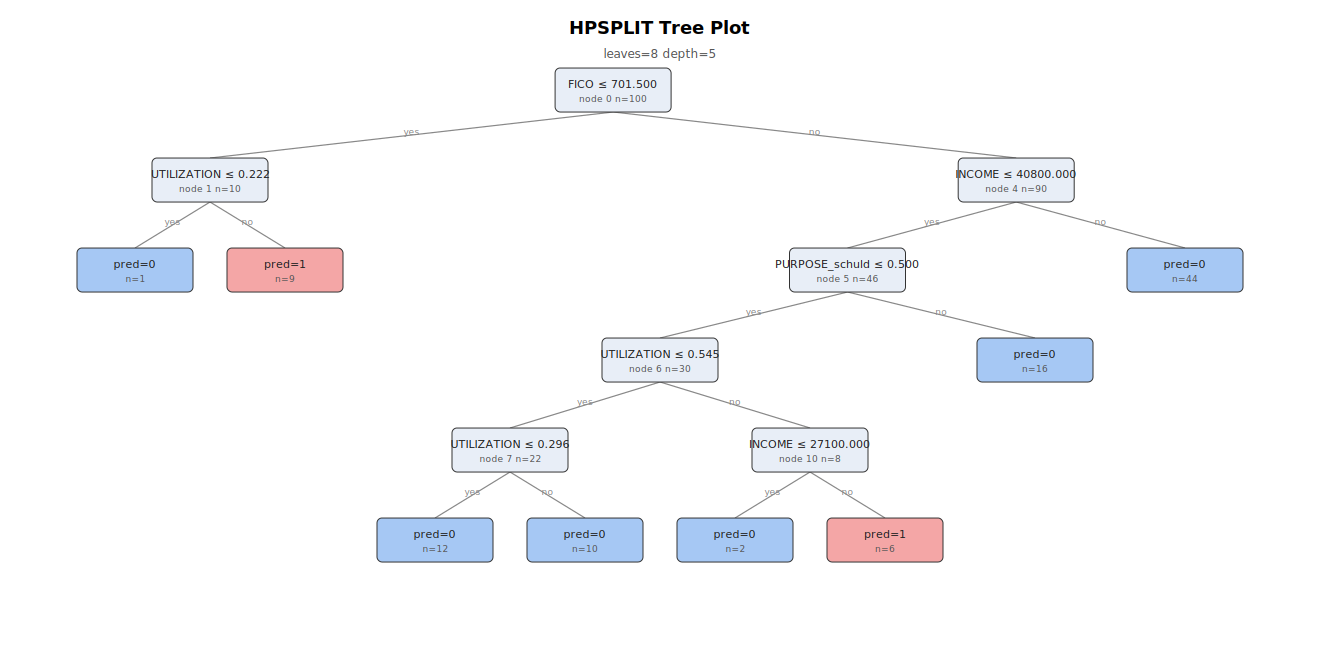

In [2]:
ODS GRAPHICS ON;

PROCEDURE hpsplit GEGEVENS=applicants seed=20260531
             PLOTS=(wholetree roc);
   label default = 'Wanbetaling' home = 'Woonsituatie' purpose = 'Leendoel'
         dti = 'Schuld-Inkomenratio' utilization = 'Kredietgebruik'
         fico = 'FICO-score' credit_age = 'Kredietgeschiedenis (jaren)'
         n_delinq = 'Aantal Achterstanden' loan_amount = 'Leningbedrag'
         income = 'Inkomen';
   KLASSE default home purpose;
   MODEL default (EVENT='1') =
         dti utilization fico credit_age n_delinq
         loan_amount income home purpose;
   grow entropy;
   prune costcomplexity;
UITVOEREN;

De **Fitstatistieken** (nauwkeurigheid, misclassificatiegraad, log-verlies) en de **ROC/AUC per klasse** laten zien hoe scherp de gesnoeide boom wanbetalers scheidt van niet-wanbetalers. De **Variabelenbelang**-tabel rangschikt welke kenmerken de splitsingen aandrijven — hier domineren **kredietgebruik** en **FICO**, gevolgd door **leendoel**, precies de hendels die een kredietbeleid zou benadrukken. De **hele-boomplot** hieronder legt de gekozen splitsingen uit als een knoop-linkdiagram: elke interne knoop toont zijn `kenmerk ≤ drempel`-regel, en elk blad is gekleurd naar zijn voorspelde klasse (rood = voorspelde wanbetaling, blauw = voorspelde niet-wanbetaling) en gelabeld met zijn steekproefgrootte.

## 3. Inzoomen op de belangrijkste splitsingen en elke aanvrager scoren

De ROC-plot hierboven visualiseert de afweging tussen het opsporen van wanbetalers en vals alarm; de AUC kwantificeert het algehele rangschikkend vermogen. Vervolgens vergroten we de bovenste twee niveaus van de boom — de splitsingen met de meeste informatie die een analist zou vertalen naar acceptatieregels — en leggen we scores per waarneming vast in een uitvoerdataset zodat we voorspellingen stroomafwaarts kunnen controleren.


                                                 The HPSPLIT Procedure                                                  

  Response variable: Wanbetaling
  Class variable: Wanbetaling
  Class variable: Woonsituatie
  Class variable: Leendoel
  Predictor variable: Schuld-Inkomenratio
  Predictor variable: Kredietgebruik
  Predictor variable: FICO-score
  Predictor variable: Kredietgeschiedenis (jaren)
  Predictor variable: Aantal Achterstanden
  Predictor variable: Leningbedrag
  Predictor variable: Inkomen
  Predictor variable: Woonsituatie
  Predictor variable: Leendoel

Model Information
Response Variable         DEFAULT
Event Level               1
Split Criterion           Entropy
Pruning Method            Cost-Complexity
Random Seed               20260531
Number of Observations    100

Predictors
    1. DTI
    2. UTILIZATION
    3. FICO
    4. CREDIT_AGE
    5. N_DELINQ
    6. LOAN_AMOUNT
    7. INCOME
    8. HOME
    9. PURPOSE

Number of Leaves          8
Final Tree Depth     


NOTE: PROC HPSPLIT data=applicants

NOTE: HPSPLIT OUTPUT OUT= dataset written to ./work/4a5175e1-9892-465c-8252-dc6c2e755a3b/scored.avro
NOTE: ODS plot written: HPSplitZoomedTree.svg
NOTE: PROC HPSPLIT completed.
NOTE: PROC PRINT data=scored

NOTE: PROC PRINT completed: 10 observations printed, 3 variables


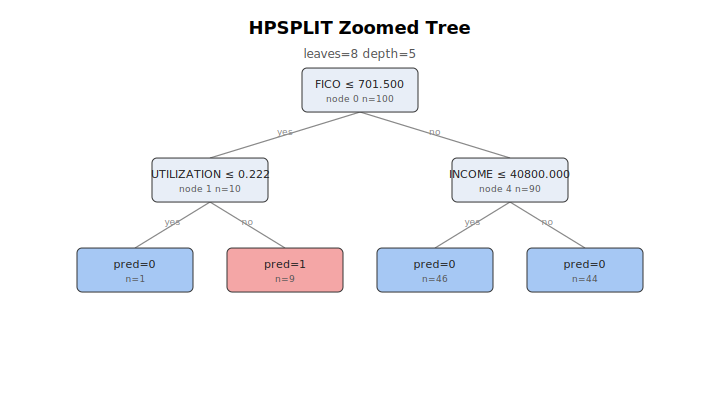

In [3]:
PROCEDURE hpsplit GEGEVENS=applicants seed=20260531
             PLOTS=zoomedtree(nodes=('0') depth=2);
   label default = 'Wanbetaling' home = 'Woonsituatie' purpose = 'Leendoel'
         dti = 'Schuld-Inkomenratio' utilization = 'Kredietgebruik'
         fico = 'FICO-score' credit_age = 'Kredietgeschiedenis (jaren)'
         n_delinq = 'Aantal Achterstanden' loan_amount = 'Leningbedrag'
         income = 'Inkomen';
   KLASSE default home purpose;
   MODEL default (EVENT='1') =
         dti utilization fico credit_age n_delinq
         loan_amount income home purpose;
   grow entropy;
   prune costcomplexity;
   UITVOER out=scored;
UITVOEREN;

PROCEDURE AFDRUKKEN GEGEVENS=scored(obs=10);
   VARIABELE p_default1 _node_ _leaf_;
UITVOEREN;

De `zoomedtree`-plot vergroot de bovenste twee niveaus van de boom — de splitsingen met de meeste informatie die een analist zou vertalen naar acceptatieregels. De `OUTPUT OUT=`-dataset bevat de voorspelde wanbetalingskans van elke aanvrager (`P_DEFAULT1`) plus de toegewezen knoop en het blad (`_NODE_`, `_LEAF_`), zodat risico- en auditteams elke individuele beslissing kunnen terugvoeren door de boom en aanvragers kunnen rangschikken naar gemodelleerd risico.

## 4. Inzetbare scoringscode exporteren

De waarde van een interpreteerbaar model is dat het inzetbaar is. `CODE FILE=` schrijft een zelfstandige DATA-stap — een geneste keten van `IF/THEN`-splitsingen die eindigt in een voorspelde wanbetalingskans en -klasse — die de score van de boom reproduceert voor elk nieuw aanvraagbestand, zonder dat een modelserver nodig is.

In [4]:
PROCEDURE hpsplit GEGEVENS=applicants seed=20260531;
   label default = 'Wanbetaling' home = 'Woonsituatie' purpose = 'Leendoel'
         dti = 'Schuld-Inkomenratio' utilization = 'Kredietgebruik'
         fico = 'FICO-score' credit_age = 'Kredietgeschiedenis (jaren)'
         n_delinq = 'Aantal Achterstanden' loan_amount = 'Leningbedrag'
         income = 'Inkomen';
   KLASSE default home purpose;
   MODEL default (EVENT='1') =
         dti utilization fico credit_age n_delinq
         loan_amount income home purpose;
   grow entropy;
   prune costcomplexity;
   code file='credit_scorecard.sas';
UITVOEREN;


                                                 The HPSPLIT Procedure                                                  

  Response variable: Wanbetaling
  Class variable: Wanbetaling
  Class variable: Woonsituatie
  Class variable: Leendoel
  Predictor variable: Schuld-Inkomenratio
  Predictor variable: Kredietgebruik
  Predictor variable: FICO-score
  Predictor variable: Kredietgeschiedenis (jaren)
  Predictor variable: Aantal Achterstanden
  Predictor variable: Leningbedrag
  Predictor variable: Inkomen
  Predictor variable: Woonsituatie
  Predictor variable: Leendoel

Model Information
Response Variable         DEFAULT
Event Level               1
Split Criterion           Entropy
Pruning Method            Cost-Complexity
Random Seed               20260531
Number of Observations    100

Predictors
    1. DTI
    2. UTILIZATION
    3. FICO
    4. CREDIT_AGE
    5. N_DELINQ
    6. LOAN_AMOUNT
    7. INCOME
    8. HOME
    9. PURPOSE

Number of Leaves          8
Final Tree Depth     


NOTE: PROC HPSPLIT data=applicants

NOTE: PROC HPSPLIT completed.


## Interpretatie van de resultaten

De gesnoeide entropieboom geeft het risicoteam een compacte, controleerbare kredietscorecard:

- **De splitsingen coderen beleid.** De dominante splitsingen — op doorlopend kredietgebruik en FICO, dan leendoel en DTI — zijn precies de drempels die een acceptatieteam kan omzetten in harde afkapregels. De hele-boomplot legt elke splitsingsvoorwaarde en elk blad in één diagram vast.
- **Kostencomplexiteitssnoei** voorkomt dat de boom ruis onthoudt; de fitstatistieken (nauwkeurigheid, misclassificatiegraad, log-verlies) vatten samen hoe scherp de boom de twee klassen scheidt.
- **Variabelenbelang en de ROC/AUC** rechtvaardigen welke kenmerken een plaats verdienen in de scorecard en documenteren het onderscheidend vermogen voor modelrisicobeheer.
- **`CODE FILE=` maakt het operationeel** — de gegenereerde DATA-stap scoort nieuwe aanvragers identiek aan deze run, zodat het gebouwde model exact het model is dat live gaat.

Bij een klein aanvragersbestand fit de boom de trainingsgegevens strak; in productie zou je hem laten groeien op de volledige portefeuille, een validatiepartitie achterhouden, de kansdrempel kalibreren op de verwachte-verlies-economie van de bank (de kosten van een gemiste wanbetaling versus een geweigerde goede klant) in plaats van een naïeve 0,5, en de boom vernieuwen naarmate de portefeuillemix verschuift.